In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.distribution_functions.sampling import sample_df_potential
from phoenix.distribution_functions.spheroid import f_double_power_law
from phoenix.potentials.potentials import nfw_potential, miyamoto_nagai_potential, plummer_potential

# 1. SETUP POTENTIAL & DF PARAMETERS

In [2]:
# Physical parameters for the potential (Masses in M_sun, Distances in kpc)
M_halo = 1e12
a_halo = 20.0
M_bulge = 1e10 
a_bulge = 1.0

# Set Disk mass to exactly zero! (Keep a and b as dummies for the network shape)
M_disk = 0.0
a_disk = 3.0 
b_disk = 0.3 

def total_potential(x, y, z):
    """Combined gravitational potential (Halo + Bulge)."""
    phi_halo = nfw_potential(x, y, z, M_halo, a_halo)
    phi_bulge = plummer_potential(x, y, z, M_bulge, a_bulge)
    return phi_halo + phi_bulge

In [3]:
# Parameters for the Double Power-Law Spheroid DF
df_params = {
    "N0_spheroid": 1e10,    # Normalization scale (roughly M_bulge)
    "J0_spheroid": 100.0,   # Transition action scale
    "Gamma_spheroid": 1.5,  # Inner slope
    "Beta_spheroid": 4.5,   # Outer slope
    "eta_spheroid": 1.0     # Sharpness of transition
}

In [4]:
# Parameters required by the Phoenix Neural Network
# (Must match the exact structure used during training: Masses scaled by 1e11)
nn_potential_params = np.array([
    M_halo / 1e11, a_halo,
    M_disk / 1e11, a_disk, b_disk,
    M_bulge / 1e11, a_bulge
])

In [5]:
# Small wrapper so the Spheroid DF matches the sampling signature expected by sample_df_potential
def spheroid_df_wrapper(Jr, Jz, Jphi, Phi_xyz, theta, params):
    return f_double_power_law(Jr, Jz, Jphi, params)


# 2. DIFFERENTIABLE SAMPLING

In [6]:
print("Starting differentiable action sampling (Bulge DF)...")
N_samples = 100_000
key = jax.random.PRNGKey(42)

# Estimate max DF value using a typical inner-bulge orbit (J_R=10, J_Z=10, L_Z=10)
test_val = spheroid_df_wrapper(10.0, 10.0, 10.0, total_potential, (), df_params)
envelope_max = float(test_val) * 2.0 

# Sample the DF using the soft acceptance logic
# Bounds: Spheroids are "hot", so we use roughly isotropic, wide bounds
candidates, soft_weights = sample_df_potential(
    df=spheroid_df_wrapper,
    key=key,
    params=df_params,
    Phi_xyz=total_potential,
    theta=(),
    n_candidates=N_samples,
    envelope_max=envelope_max,
    J_bounds=(500.0, 500.0, 500.0), 
    tau=0.05
)

# Generate uniform random angles [0, 2*pi]
key, subkey = jax.random.split(key)
angles = jax.random.uniform(subkey, shape=(N_samples, 3), minval=0.0, maxval=2*jnp.pi)


Starting differentiable action sampling (Bulge DF)...


# 3. MAPPING ACTIONS TO PHASE SPACE

In [7]:
print("Mapping actions to phase space using Phoenix Surrogate...")
mapper = PhoenixMapper()

potentials_batch = np.tile(nn_potential_params, (N_samples, 1))

# Convert to NumPy for easier manipulation
candidates_np = np.array(candidates)

# Fix net rotation: Our sampler only generates positive Lz. 
# A classical bulge shouldn't spin, so we randomly flip 50% of the Lz signs.
flip_mask = np.random.choice([-1.0, 1.0], size=N_samples)
candidates_np[:, 2] = candidates_np[:, 2] * flip_mask

# Execute the Neural Network Mapping
phase_space = mapper.map_to_phase_space(candidates_np, np.array(angles), potentials_batch)
x, y, z = phase_space[:, 0], phase_space[:, 1], phase_space[:, 2]
vx, vy, vz = phase_space[:, 3], phase_space[:, 4], phase_space[:, 5]
weights = np.array(soft_weights)

Mapping actions to phase space using Phoenix Surrogate...
Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz
Model loaded and ready for inference!


# 4. PLOTTING SPATIAL PLANES

Generating Spatial Density plots...


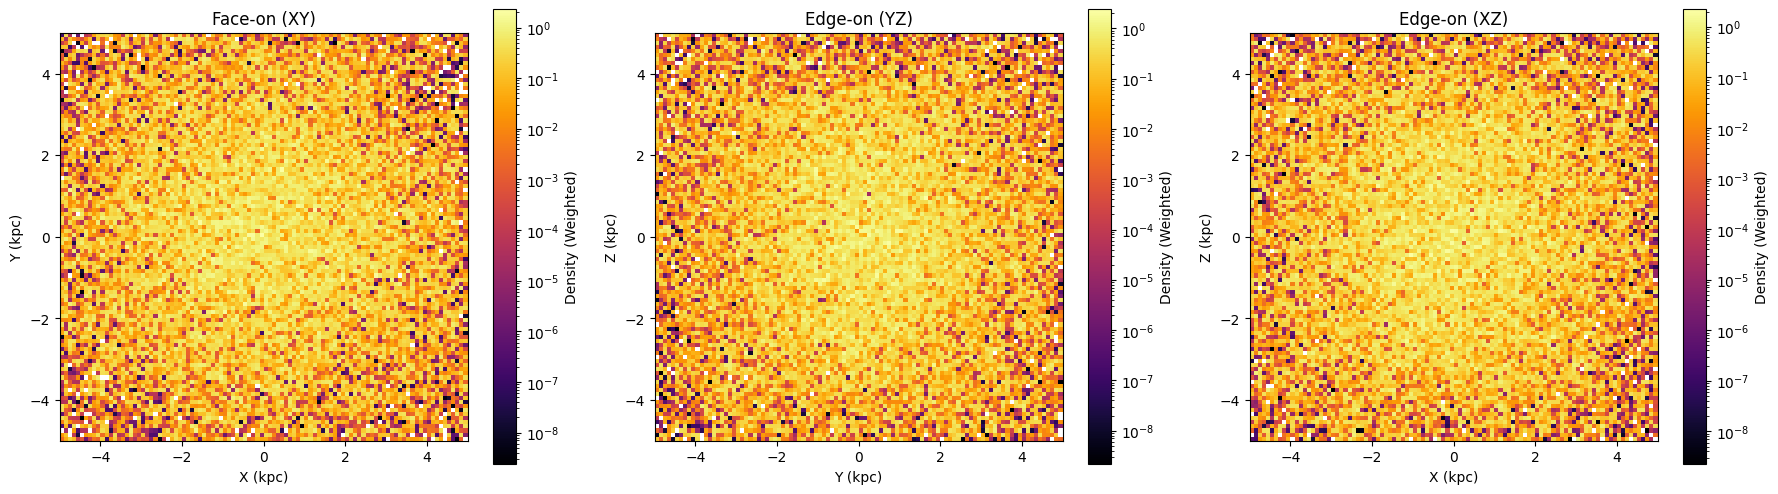

In [8]:
print("Generating Spatial Density plots...")
fig_space, axes_space = plt.subplots(1, 3, figsize=(18, 5))

# We use hist2d with 'weights' to apply the soft acceptance mask!
planes = [(x, y, 'X (kpc)', 'Y (kpc)', 'Face-on (XY)'),
          (y, z, 'Y (kpc)', 'Z (kpc)', 'Edge-on (YZ)'),
          (x, z, 'X (kpc)', 'Z (kpc)', 'Edge-on (XZ)')]

for i, (coord1, coord2, xlabel, ylabel, title) in enumerate(planes):
    ax = axes_space[i]
    # Zoomed in a bit more since bulges are compact
    h = ax.hist2d(coord1, coord2, bins=100, range=[[-5, 5], [-5, 5]], 
                  weights=weights, cmap='inferno', norm=LogNorm())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_aspect('equal')
    fig_space.colorbar(h[3], ax=ax, label='Density (Weighted)')

plt.tight_layout()
plt.show()


# 5. GAUSS-HERMITE LINE-OF-SIGHT KINEMATICS

In [9]:
print("Generating Gauss-Hermite Kinematic maps (Edge-on XZ projection)...")

def gauss_hermite(v, v_rot, v_disp, h3, h4):
    """Gauss-Hermite expansion for line-of-sight velocity distribution."""
    y = np.asarray((np.asarray(v) - v_rot) / (v_disp))
    return (np.exp(-0.5 * y**2)/(v_disp*np.sqrt(2*np.pi)) )* (
        1
        + h3 * ((2 * np.sqrt(2) * y**3 - 3 * np.sqrt(2) * y) / np.sqrt(6))
        + h4 * ((4 * y**4 - 12 * y**2 + 3) / np.sqrt(24))
    )

def fit_losvd_weighted(v_bin, w_bin):
    """Fit Gauss-Hermite expansion to a soft-weighted velocity distribution."""
    if len(v_bin) < 10 or np.sum(w_bin) < 1.0:
        return np.nan, np.nan, np.nan, np.nan
        
    hist, bins = np.histogram(v_bin, bins=30, density=True, weights=w_bin)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    V_guess = np.average(v_bin, weights=w_bin)
    variance = np.average((v_bin - V_guess)**2, weights=w_bin)
    sigma_guess = np.sqrt(variance)
    
    if sigma_guess == 0:
        return V_guess, 0.0, 0.0, 0.0
        
    p0 = [V_guess, sigma_guess, 0.1, 0.1]
    
    try:
        popt, _ = curve_fit(gauss_hermite, bin_centers, hist, p0=p0, maxfev=10000)
    except (RuntimeError, ValueError, TypeError):
        return np.nan, np.nan, np.nan, np.nan
        
    return popt

def compute_kinematic_maps(c1, c2, v_los, weights_arr, bins1, bins2):
    """Helper function to bin particles and compute GH maps for a given projection."""
    grid1 = len(bins1) - 1
    grid2 = len(bins2) - 1
    
    V_map = np.zeros((grid2, grid1))
    sigma_map = np.zeros((grid2, grid1))
    h3_map = np.zeros((grid2, grid1))
    h4_map = np.zeros((grid2, grid1))

    for i in range(grid1):
        for j in range(grid2):
            mask = (c1 >= bins1[i]) & (c1 < bins1[i+1]) & (c2 >= bins2[j]) & (c2 < bins2[j+1])
            w_bin = weights_arr[mask]
            
            if np.sum(w_bin) < 1.0 or len(v_los[mask]) < 10: 
                V_map[j, i], sigma_map[j, i] = np.nan, np.nan
                h3_map[j, i], h4_map[j, i] = np.nan, np.nan
                continue
                
            v_bin = v_los[mask]
            v_rot, v_disp, h3, h4 = fit_losvd_weighted(v_bin, w_bin)
            
            V_map[j, i] = v_rot
            sigma_map[j, i] = v_disp
            h3_map[j, i] = h3
            h4_map[j, i] = h4
            
    return V_map, sigma_map, h3_map, h4_map

def plot_kinematic_grid(V, sigma, h3, h4, extent, xlabel, ylabel, title, v_range, sig_range):
    """Helper to consistently plot the 4 kinematic maps."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(title, fontsize=16)
    axes = axes.flatten()

    maps = [
        (V, 'LOS Velocity ($V$)', 'coolwarm', -v_range, v_range),
        (sigma, 'Dispersion ($\sigma$)', 'viridis', 0, sig_range),
        (h3, 'GH $h_3$ (Asymmetry)', 'PiYG', -0.15, 0.15),
        (h4, 'GH $h_4$ (Tails)', 'PuOr', -0.15, 0.15)
    ]

    for i, (data, m_title, cmap, vmin, vmax) in enumerate(maps):
        ax = axes[i]
        im = ax.imshow(data, origin='lower', extent=extent, 
                       cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(m_title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

# Zoom in on the bulge area (e.g. 5 kpc instead of 15 kpc for the disk)
grid_size = 30
x_bins = np.linspace(-5, 5, grid_size + 1)
y_bins = np.linspace(-5, 5, grid_size + 1)
z_bins = np.linspace(-5, 5, grid_size + 1)


Generating Gauss-Hermite Kinematic maps (Edge-on XZ projection)...


<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_938841/3485109488.py:74: SyntaxWarning: invalid escape sequence '\s'
  (sigma, 'Dispersion ($\sigma$)', 'viridis', 0, sig_range),


# A. EDGE-ON KINEMATICS (Projection: XZ Plane | LOS: Y-axis)

Computing Edge-On (XZ) maps...


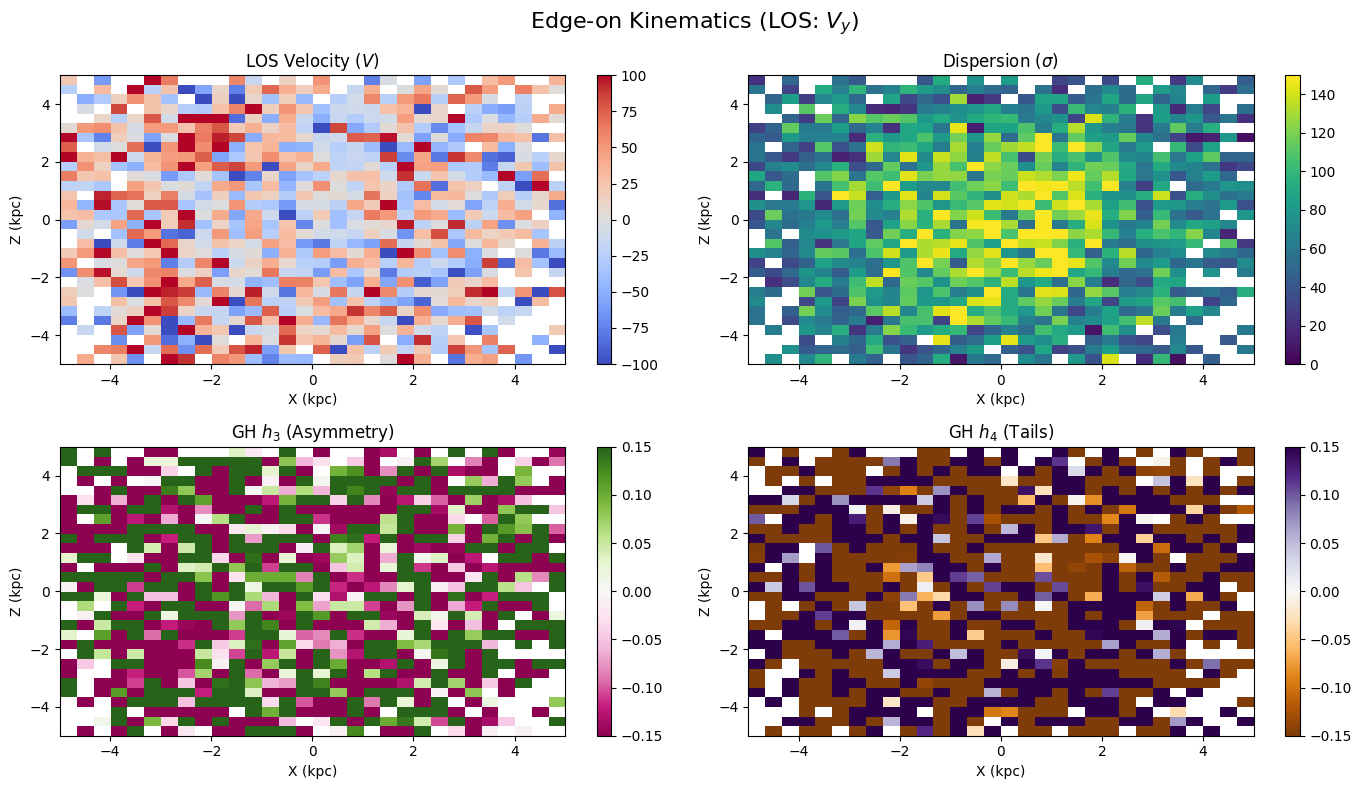

In [10]:
print("Computing Edge-On (XZ) maps...")
V_edge, sig_edge, h3_edge, h4_edge = compute_kinematic_maps(
    c1=x, c2=z, v_los=vy, weights_arr=weights, bins1=x_bins, bins2=z_bins
)
plot_kinematic_grid(
    V_edge, sig_edge, h3_edge, h4_edge, 
    extent=[x_bins[0], x_bins[-1], z_bins[0], z_bins[-1]], 
    xlabel='X (kpc)', ylabel='Z (kpc)', 
    title='Edge-on Kinematics (LOS: $V_y$)', 
    v_range=100,      # Bulges have low rotation
    sig_range=150    # Bulges have high dispersion!
)

# B. FACE-ON KINEMATICS (Projection: XY Plane | LOS: Z-axis)

Computing Face-On (XY) maps...


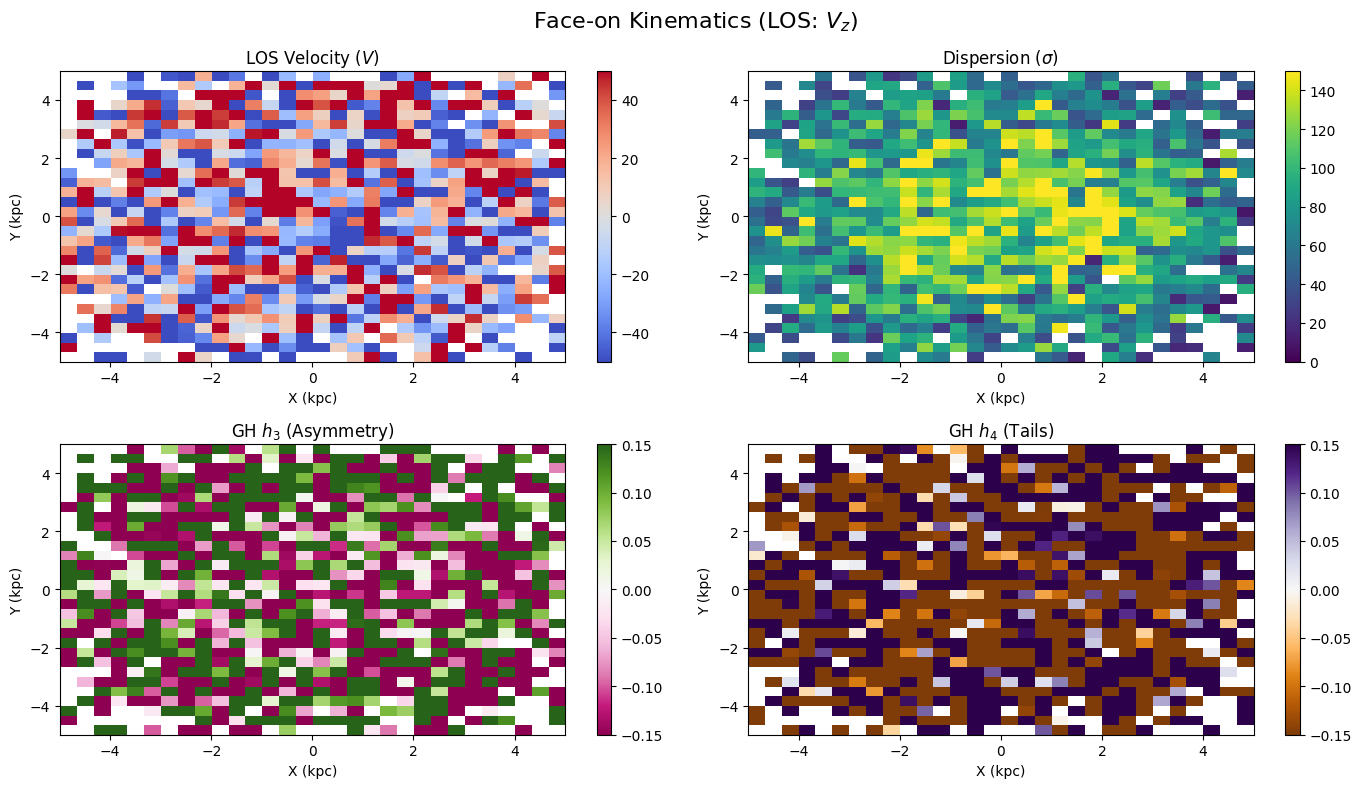

In [11]:
print("Computing Face-On (XY) maps...")
V_face, sig_face, h3_face, h4_face = compute_kinematic_maps(
    c1=x, c2=y, v_los=vz, weights_arr=weights, bins1=x_bins, bins2=y_bins
)
plot_kinematic_grid(
    V_face, sig_face, h3_face, h4_face, 
    extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]], 
    xlabel='X (kpc)', ylabel='Y (kpc)', 
    title='Face-on Kinematics (LOS: $V_z$)', 
    v_range=50,
    sig_range=150
)